# Exact Diagonalization

Exact diagonalization is a numerical method that involves directly solving for the eigenvalues and eigenvectors of the Hamiltonian. In this instance, we will use this method to understand the $k$ interaction by turning off the the $J$ and $h$ parameters:

$$ \mathcal{H_k} = \sum_i k_R(\sigma_i^x \sigma_{i+2}^y- \sigma_i^z\sigma_{i+1}^y\sigma_{i+2}^x)+k_L(\sigma_i^x\sigma_{i+1}^y\sigma_{i+2}^z - \sigma_{i}^y\sigma_{i+2}^x) $$

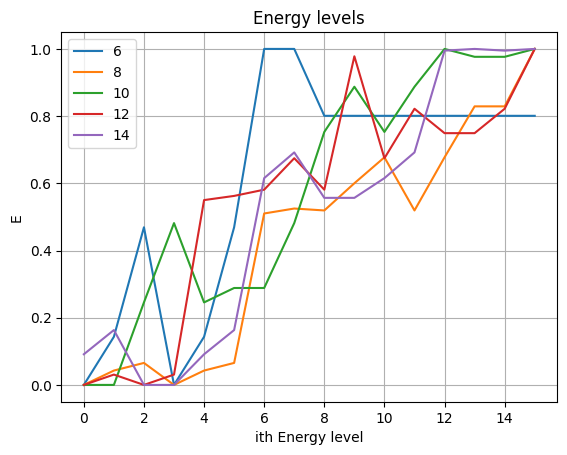

In [ ]:
from ed_utils import *

J = 0
h = 0
k_l = 1
k_r = k_l
eL = [6, 8, 10, 12, 14]

for L in eL:
    H = Ham(J, h, k_l, k_r, L)  # create the Hamiltonian
    N = 16  # number of energy levels
    E, psi = lg.eigsh(H, k=16, which='SA')
    psi0 = psi.T[0] # ground state
    E -= np.min(E)
    E /= np.abs(np.max(E) - np.min(E))
    
    # energy
    plt.plot(range(N), E, label=f"{L}")

    # magnetization profile
    # i = [i for i in range(L)]
    # mag = []
    # for site in i:
    #     mag.append(operator(site, X, psi0))
    
    # plt.plot([L for _ in range(L)], mag, label=f"{L}")

plt.title("Energy levels")
plt.xlabel("ith Energy level")
plt.ylabel("E")
plt.grid()
plt.legend()
plt.show()

# Reimplementation using QuSpin

In [14]:
from quspin import *
import numpy as np
import matplotlib.pyplot as plt